In [2]:
"""Basit GluonTS DeepAR örneği.

Bu betik, GluonTS belgelerindeki "Simple Example" akışını
takip ederek AirPassengers verisinde bir DeepAR modeli eğitir,
tahmin üretir ve sonuçları çizer.
"""

from __future__ import annotations

import pandas as pd
import matplotlib.pyplot as plt

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from gluonts.torch import DeepAREstimator


def load_air_passengers_dataframe() -> pd.DataFrame:
    """AirPassengers verisini pandas DataFrame olarak yükler."""
    csv_url = (
        "https://raw.githubusercontent.com/AileenNielsen/"
        "TimeSeriesAnalysisWithPython/master/data/AirPassengers.csv"
    )
    dataframe = pd.read_csv(csv_url, index_col=0, parse_dates=True)
    return dataframe

In [3]:
def build_dataset(dataframe: pd.DataFrame) -> PandasDataset:
    """Veriyi GluonTS PandasDataset formatına dönüştürür."""
    dataset = PandasDataset(dataframe, target="#Passengers")
    return dataset

In [4]:
def train_deepar(training_data):
    """DeepAR modeli kurar ve eğitir; tahminci döndürür."""
    estimator = DeepAREstimator(
        prediction_length=12,
        freq="M",
        trainer_kwargs={"max_epochs": 5},
    )
    predictor = estimator.train(training_data)
    return predictor

In [5]:
def plot_forecasts(dataframe: pd.DataFrame, forecasts) -> None:
    """Gerçek değerleri ve çoklu pencere tahminlerini çizer."""
    plt.figure(figsize=(10, 5))
    plt.plot(dataframe["1954":], color="black")
    for forecast in forecasts:
        forecast.plot()
    plt.legend(["Gerçek değerler"], loc="upper left", fontsize="large")
    plt.title("DeepAR - AirPassengers Tahminleri")
    plt.tight_layout()
    plt.show()

In [6]:
def main() -> None:
    dataframe = load_air_passengers_dataframe()
    dataset = build_dataset(dataframe)

    training_data, test_generator = split(dataset, offset=-36)
    test_data = test_generator.generate_instances(
        prediction_length=12,
        windows=3,
    )

    predictor = train_deepar(training_data)
    forecasts = list(predictor.predict(test_data.input))

    plot_forecasts(dataframe, forecasts)

c:\Users\emreq\Desktop\Code - Lib - Denemeler\.venv\Lib\site-packages\gluonts\time_feature\_base.py:249: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = to_offset(freq_str)
c:\Users\emreq\Desktop\Code - Lib - Denemeler\.venv\Lib\site-packages\gluonts\time_feature\lag.py:104: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  offset = to_offset(freq_str)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\emreq\Desktop\Code - Lib - Denemeler\.venv\Lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4060') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision f

Training: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 50: 'train_loss' reached 5.81311 (best 5.81311), saving model to 'c:\\Users\\emreq\\Desktop\\Code - Lib - Denemeler\\Time Series\\lightning_logs\\version_0\\checkpoints\\epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'train_loss' reached 4.83166 (best 4.83166), saving model to 'c:\\Users\\emreq\\Desktop\\Code - Lib - Denemeler\\Time Series\\lightning_logs\\version_0\\checkpoints\\epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'train_loss' reached 4.70913 (best 4.70913), saving model to 'c:\\Users\\emreq\\Desktop\\Code - Lib - Denemeler\\Time Series\\lightning_logs\\version_0\\checkpoints\\epoch=2-step=150.ckpt' as top 1
Epoch 3, global step 200: 'train_loss' reached 4.41916 (best 4.41916), saving model to 'c:\\Users\\emreq\\Desktop\\Code - Lib - Denemeler\\Time Series\\lightning_logs\\version_0\\checkpoints\\epoch=3-step=200.ckpt' as top 1
Epoch 4, global step 250: 'train_loss' reached 4.27800 (best 4.27800), saving model to 'c:\\Users\\emreq\\

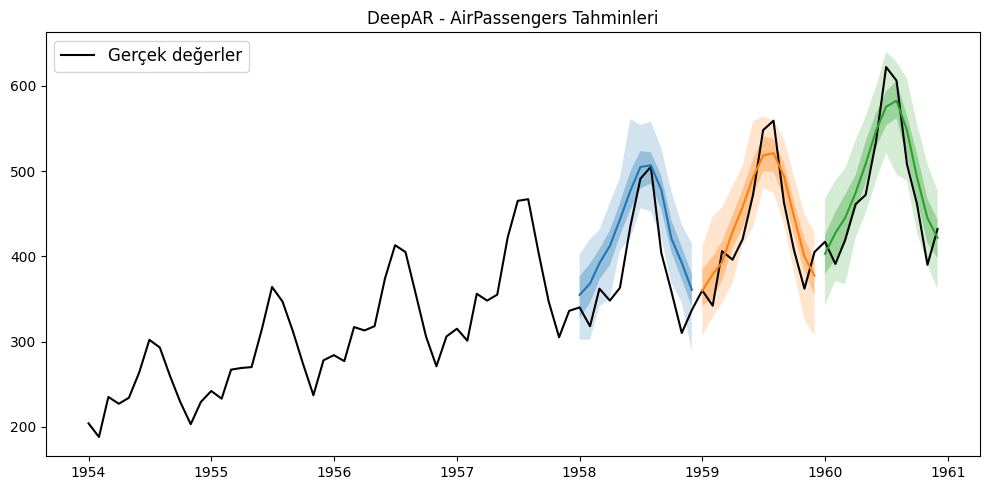

In [7]:
if __name__ == "__main__":
    main()
